In [1]:
import pandas as pd
import numpy as np
import os
import pdf_to_text
import embed_documents
import ask_mistral
from mistralai import Mistral
from dotenv import load_dotenv
import faiss
import json
from transformers import AutoTokenizer, AutoModel
from transformers import logging
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\jacqu\VSC_Projects\M2_EngineeringProject\Basic-RAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set the logging level to ERROR to suppress warnings
logging.set_verbosity_error()

load_dotenv()

True

In [3]:
# Get the directory of the notebook (src/)
notebook_dir = os.path.dirname(os.path.abspath("__file__"))

# Navigate to the root directory (one level up from src/)
root_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
os.chdir(root_dir)

In [4]:
# Config
documents_folder = "data/documents/"
extracted_text_folder = "data/extracted_text/"
index_folder = "data/faiss_vector_base/"
api_key = os.environ["MISTRAL_API_KEY"]
dimension = 768
top_k = 10
excel_file = "data/distance_analysis/CyberIA - Dataset.xlsx"
output_excel_file = "data/distance_analysis/CyberIA - Dataset - Distances.xlsx"

In [5]:
# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/multi-qa-mpnet-base-cos-v1")
model = AutoModel.from_pretrained("sentence-transformers/multi-qa-mpnet-base-cos-v1")

In [6]:
# Extract text if not already done
if not os.path.isdir(extracted_text_folder):
    pdf_to_text.extract_text_from_each_document(documents_folder=documents_folder, extracted_text_folder=extracted_text_folder)

In [7]:
# Create FAISS index if not already done
if not os.path.isdir(index_folder):
    embed_documents.create_faiss_index_and_embeddings_if_not_exists(
        tokenizer=tokenizer,
        embeddings_model=model,
        index_folder=index_folder,
        extracted_text_folder=extracted_text_folder,
        dimension=dimension
    )
    faiss_index_file = os.path.join(index_folder, "faiss_index_with_metadata.bin")
    metadata_file = os.path.join(index_folder, "metadata.json")
else:
    faiss_index_file = os.path.join(index_folder, "faiss_index_with_metadata.bin")
    metadata_file = os.path.join(index_folder, "metadata.json")

In [8]:
# Load FAISS index and metadata
if not os.path.exists(faiss_index_file) or not os.path.exists(metadata_file):
    raise FileNotFoundError("FAISS index or metadata file not found.")
index = faiss.read_index(faiss_index_file)
with open(metadata_file, "r") as f:
    metadata = json.load(f)

# Number of documents
print("Number of documents:", index.ntotal)

Number of documents: 5623


In [9]:
client = Mistral(api_key=api_key)

# Read the Excel file
if not os.path.exists(excel_file):
    raise FileNotFoundError(f"Excel file {excel_file} not found.")
df = pd.read_excel(excel_file)
df

,Category,Questions,Answers,DOC,Source
0,General,What are the primary objectives of the HIPAA S...,"To ensure the confidentiality, integrity, and ...",HIPAA Administrative Simplification,HIPAA Security Rule Introduction
1,General,What is the role of risk analysis under the HI...,Conducting risk analysis helps identify potent...,HIPAA Administrative Simplification,§164.308(a)(1)(ii)(A) - Risk Analysis
2,General,Describe the responsibilities of covered entit...,Covered entities must implement policies and p...,HIPAA Administrative Simplification,§164.308(a)(4) - Access Controls
3,Technical,What are the required technical safeguards out...,"Safeguards include access control, audit contr...",HIPAA Administrative Simplification,§164.312 - Technical Safeguards
4,Technical,Explain the role of encryption in securing ePH...,Encryption protects ePHI against unauthorized ...,HIPAA Administrative Simplification,§164.312(e)(2)(ii) - Transmission Security
...,...,...,...,...,...
65,Technical,"What is tokenization, and how does it enhance ...",Replacing sensitive data with unique identifie...,Tokenization Overview,PCI SSC Tokenization Guidelines
66,Compliance,How does PCI DSS enforce strong access controls?,By implementing multi-factor authentication an...,Access Control Standards,PCI DSS Req. 8
67,Compliance,What are the logging requirements under PCI DSS?,Maintaining audit logs for all access to cardh...,Logging and Monitoring Standards,PCI DSS Req. 10
68,Technical,How does PCI DSS define a secure network?,"Through the use of firewalls, secure protocols...",Secure Network Requirements,PCI DSS Req. 1


In [10]:
#Mean Pooling - Take average of all tokens
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [11]:
# Function to get text embeddings using Hugging Face model
def get_text_embedding(text, tokenizer, model):
    """
    Generates text embeddings using a Hugging Face model.
    """
    encoded_input = tokenizer(
        text,
        return_tensors="pt",
        # max_length=512,  # Model's max token limit (514 includes special tokens)
        truncation=True,  # Truncate sequences longer than max_length
    )
    with torch.no_grad():
        model_output = model(**encoded_input, return_dict=True)
        # Use mean pooling for the embedding
    embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    embeddings = F.normalize(embeddings, p=2, dim=1)
    return embeddings.numpy().squeeze()

In [12]:
def get_distances(tokenizer, embeddings_model, question, index, top_k=5):
    """
    Queries the FAISS index with a question and retrieves relevant chunks with context.
    Args:
        question (str): The query or question.
    Returns:
        list of dict: Retrieved chunks with metadata.
        list of float: Distances between the query and retrieved vectors.
    """

    top_k = index.ntotal

    # Get the embedding of the question
    question_embedding = get_text_embedding(question, tokenizer=tokenizer, model=embeddings_model)
    
    # Perform similarity search
    distances, indices = index.search(np.array([question_embedding], dtype="float32"), top_k)

    return distances[0]

In [13]:
# Ensure the DataFrame has the required columns
if "Questions" not in df.columns or "Answers" not in df.columns:
    raise ValueError("The Excel file must contain 'Question' and 'Answers' columns.")

In [14]:
# Add new columns for LLM answers and mean distances
documents_distances = []
df["Distances"] = None

# Iterate over each question
for idx, row in df.iterrows():
    question = row["Questions"]
    print(f"Processing question: {question}")
    try:
        distances = get_distances(tokenizer, model, question, index, top_k)
        documents_distances = np.append(documents_distances, distances)
        df.at[idx, "Distances"] = distances
    except Exception as e:
        print(f"Error processing question '{question}': {e}")

df

Processing question: What are the primary objectives of the HIPAA Security Rule in protecting electronic protected health information (ePHI)?
Processing question: What is the role of risk analysis under the HIPAA Security Rule for covered entities and business associates?
Processing question: Describe the responsibilities of covered entities in ensuring employee access controls to ePHI.
Processing question: What are the required technical safeguards outlined by the HIPAA Security Rule?
Processing question: Explain the role of encryption in securing ePHI during transmission.
Processing question: What steps must be taken by a covered entity when a security incident involving ePHI occurs?
Processing question: What administrative safeguards must covered entities implement to manage workforce security?
Processing question: What are the penalties for non-compliance with HIPAA's cybersecurity requirements?
Processing question: What is the purpose of contingency planning in HIPAA’s cybersecuri

,Category,Questions,Answers,DOC,Source,Distances
0,General,What are the primary objectives of the HIPAA S...,"To ensure the confidentiality, integrity, and ...",HIPAA Administrative Simplification,HIPAA Security Rule Introduction,"[0.7255768, 0.6673699, 0.6636292, 0.6486785, 0..."
1,General,What is the role of risk analysis under the HI...,Conducting risk analysis helps identify potent...,HIPAA Administrative Simplification,§164.308(a)(1)(ii)(A) - Risk Analysis,"[0.64886034, 0.6204736, 0.61212826, 0.5991803,..."
2,General,Describe the responsibilities of covered entit...,Covered entities must implement policies and p...,HIPAA Administrative Simplification,§164.308(a)(4) - Access Controls,"[0.7320908, 0.6959915, 0.6814585, 0.67958796, ..."
3,Technical,What are the required technical safeguards out...,"Safeguards include access control, audit contr...",HIPAA Administrative Simplification,§164.312 - Technical Safeguards,"[0.75675094, 0.6998489, 0.6920339, 0.6894436, ..."
4,Technical,Explain the role of encryption in securing ePH...,Encryption protects ePHI against unauthorized ...,HIPAA Administrative Simplification,§164.312(e)(2)(ii) - Transmission Security,"[0.4608245, 0.44398606, 0.43948382, 0.4172501,..."
...,...,...,...,...,...,...
65,Technical,"What is tokenization, and how does it enhance ...",Replacing sensitive data with unique identifie...,Tokenization Overview,PCI SSC Tokenization Guidelines,"[0.41426596, 0.40963396, 0.40642363, 0.3776863..."
66,Compliance,How does PCI DSS enforce strong access controls?,By implementing multi-factor authentication an...,Access Control Standards,PCI DSS Req. 8,"[0.578936, 0.5735177, 0.57077664, 0.5668055, 0..."
67,Compliance,What are the logging requirements under PCI DSS?,Maintaining audit logs for all access to cardh...,Logging and Monitoring Standards,PCI DSS Req. 10,"[0.74334186, 0.63974166, 0.62870777, 0.6225725..."
68,Technical,How does PCI DSS define a secure network?,"Through the use of firewalls, secure protocols...",Secure Network Requirements,PCI DSS Req. 1,"[0.6605567, 0.5998112, 0.591706, 0.58187324, 0..."


In [15]:
# Min and max distances
min_similarity = np.min(documents_distances)
max_similarity = np.max(documents_distances)
min_similarity, max_similarity

(np.float64(-0.18922099471092224), np.float64(0.778114914894104))

In [16]:
df.isnull().sum()

Category     0
Questions    0
Answers      0
DOC          0
Source       0
Distances    0
dtype: int64

In [17]:
df["Top_10_distances"] = df["Distances"].apply(lambda x: sorted(x)[-10:])
df["Top_10_distances_mean"] = df["Top_10_distances"].apply(lambda x: np.mean(x) if x else None)
df

,Category,Questions,Answers,DOC,Source,Distances,Top_10_distances,Top_10_distances_mean
0,General,What are the primary objectives of the HIPAA S...,"To ensure the confidentiality, integrity, and ...",HIPAA Administrative Simplification,HIPAA Security Rule Introduction,"[0.7255768, 0.6673699, 0.6636292, 0.6486785, 0...","[0.6332248, 0.6376181, 0.63827574, 0.643761, 0...",0.654833
1,General,What is the role of risk analysis under the HI...,Conducting risk analysis helps identify potent...,HIPAA Administrative Simplification,§164.308(a)(1)(ii)(A) - Risk Analysis,"[0.64886034, 0.6204736, 0.61212826, 0.5991803,...","[0.5852006, 0.5855533, 0.58602524, 0.58720696,...",0.601474
2,General,Describe the responsibilities of covered entit...,Covered entities must implement policies and p...,HIPAA Administrative Simplification,§164.308(a)(4) - Access Controls,"[0.7320908, 0.6959915, 0.6814585, 0.67958796, ...","[0.6452341, 0.6456138, 0.64757264, 0.6649873, ...",0.673845
3,Technical,What are the required technical safeguards out...,"Safeguards include access control, audit contr...",HIPAA Administrative Simplification,§164.312 - Technical Safeguards,"[0.75675094, 0.6998489, 0.6920339, 0.6894436, ...","[0.6748849, 0.6803926, 0.68302405, 0.6831584, ...",0.692977
4,Technical,Explain the role of encryption in securing ePH...,Encryption protects ePHI against unauthorized ...,HIPAA Administrative Simplification,§164.312(e)(2)(ii) - Transmission Security,"[0.4608245, 0.44398606, 0.43948382, 0.4172501,...","[0.3845813, 0.39443547, 0.40001076, 0.4008701,...",0.416702
...,...,...,...,...,...,...,...,...
65,Technical,"What is tokenization, and how does it enhance ...",Replacing sensitive data with unique identifie...,Tokenization Overview,PCI SSC Tokenization Guidelines,"[0.41426596, 0.40963396, 0.40642363, 0.3776863...","[0.3406359, 0.34381005, 0.35952225, 0.36105904...",0.374025
66,Compliance,How does PCI DSS enforce strong access controls?,By implementing multi-factor authentication an...,Access Control Standards,PCI DSS Req. 8,"[0.578936, 0.5735177, 0.57077664, 0.5668055, 0...","[0.54352635, 0.54615754, 0.5510192, 0.5513464,...",0.558911
67,Compliance,What are the logging requirements under PCI DSS?,Maintaining audit logs for all access to cardh...,Logging and Monitoring Standards,PCI DSS Req. 10,"[0.74334186, 0.63974166, 0.62870777, 0.6225725...","[0.5821527, 0.6000922, 0.6034368, 0.60674703, ...",0.626133
68,Technical,How does PCI DSS define a secure network?,"Through the use of firewalls, secure protocols...",Secure Network Requirements,PCI DSS Req. 1,"[0.6605567, 0.5998112, 0.591706, 0.58187324, 0...","[0.5642173, 0.56623447, 0.5675575, 0.5779681, ...",0.586896


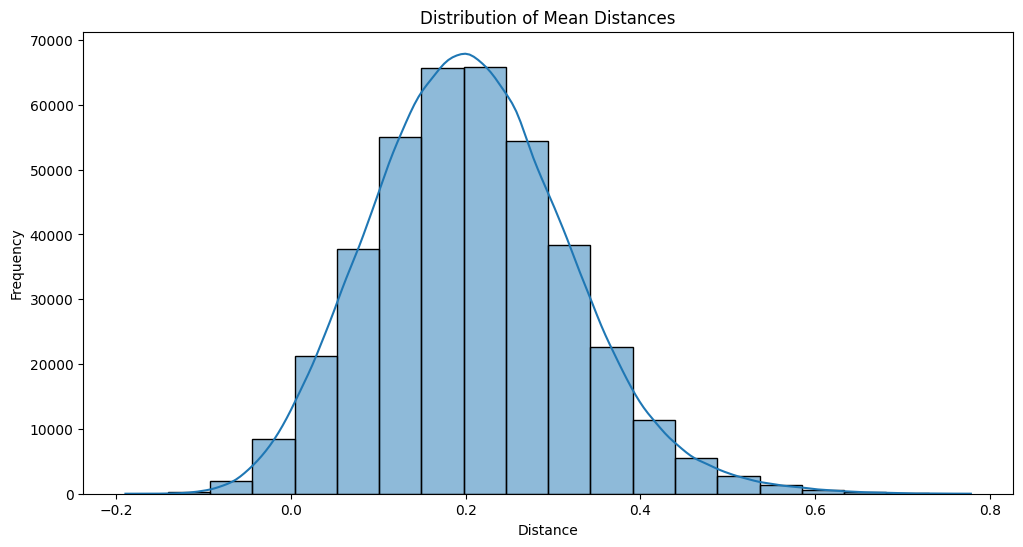

In [18]:
# Plot the distribution of the array
plt.figure(figsize=(12, 6))
sns.histplot(documents_distances, bins=20, kde=True)

# Add titles and labels
plt.title("Distribution of Mean Distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()


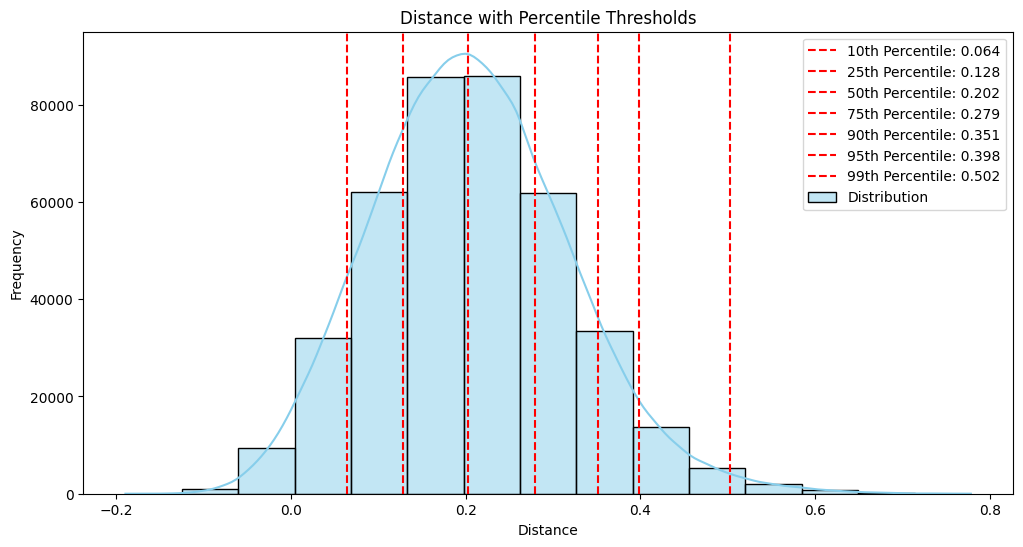

In [19]:
percentiles = np.percentile(documents_distances, [10, 25, 50, 75, 90, 95, 99])

# Plot the distribution with percentiles
plt.figure(figsize=(12, 6))
sns.histplot(documents_distances, kde=True, bins=15, color="skyblue", label="Distribution")

# Add percentile lines with unique labels
for i, p in enumerate(percentiles):
    plt.axvline(p, color="red", linestyle="--", label=f"{[10, 25, 50, 75, 90, 95, 99][i]}th Percentile: {p:.3f}")

# Avoid duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# Add labels and title
plt.title("Distance with Percentile Thresholds")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

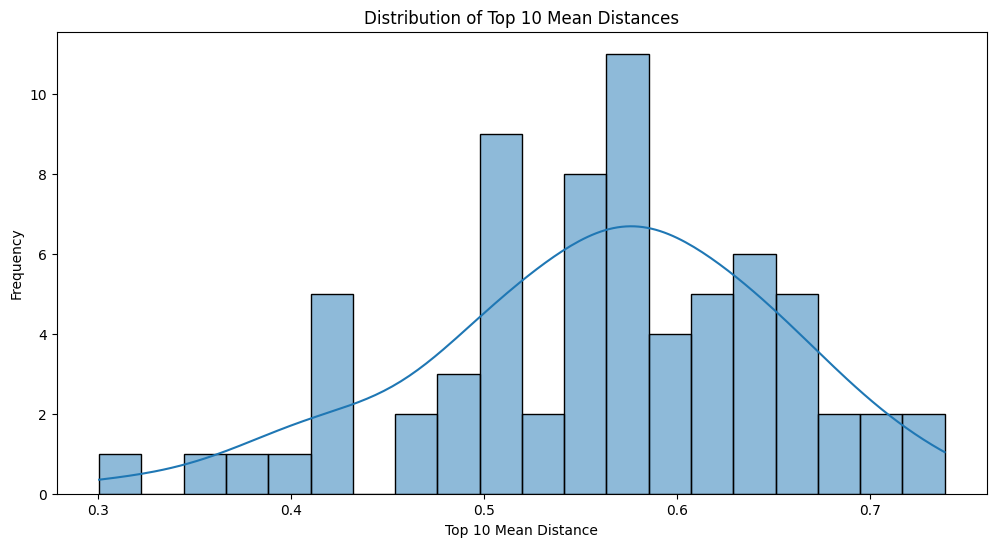

In [20]:
# Top 10 mean distances
df["Top_10_distances_mean"] = df["Top_10_distances_mean"].astype(float)

# Plot the distribution of Mean_Distance
plt.figure(figsize=(12, 6))
sns.histplot(df["Top_10_distances_mean"], bins=20, kde=True)


plt.title("Distribution of Top 10 Mean Distances")
plt.xlabel("Top 10 Mean Distance")
plt.ylabel("Frequency")
plt.show()

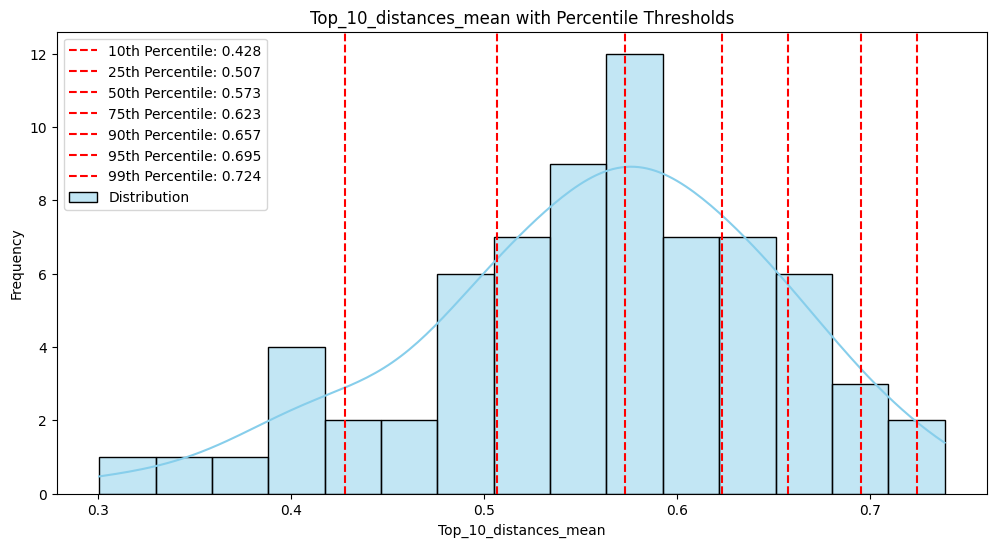

In [21]:
percentiles = np.percentile(df["Top_10_distances_mean"], [10, 25, 50, 75, 90, 95, 99])

# Plot the distribution with percentiles
plt.figure(figsize=(12, 6))
sns.histplot(df["Top_10_distances_mean"], kde=True, bins=15, color="skyblue", label="Distribution")

# Add percentile lines with unique labels
for i, p in enumerate(percentiles):
    plt.axvline(p, color="red", linestyle="--", label=f"{[10, 25, 50, 75, 90, 95, 99][i]}th Percentile: {p:.3f}")

# Avoid duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# Add labels and title
plt.title("Top_10_distances_mean with Percentile Thresholds")
plt.xlabel("Top_10_distances_mean")
plt.ylabel("Frequency")
plt.show()

In [22]:
# Get difference between min and max distances for top 10 distances
df["Top_10_distances_diff"] = df["Top_10_distances"].apply(lambda x: x[-1] - x[0] if x else None)

<Axes: xlabel='Top_10_distances_diff', ylabel='Count'>

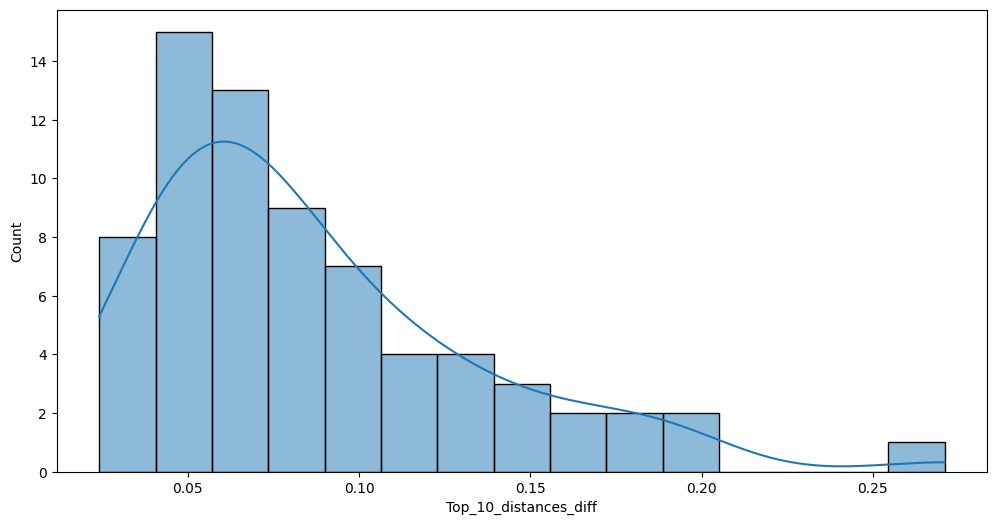

In [23]:
# Visualize the distribution of the differences
plt.figure(figsize=(12, 6))
sns.histplot(df["Top_10_distances_diff"], bins=15, kde=True)

In [24]:
df["Top_10_distances_diff"].max()

np.float32(0.27097112)

In [25]:
df["Top_10_distances_diff"].min()

np.float32(0.02408272)

In [26]:
df["Top_10_distances_diff"].mean()

np.float32(0.086334094)

In [27]:
# Value of 50th percentile of Top_10_distances_mean 
df["Top_10_distances_mean"].median()

np.float64(0.5728583931922913)